В качестве используемого датасета, я возьму conll03 (классический датасет для NER). Он упоминается в статье, как один из пяти используемых.  
В качестве используемой модели, возьму дообученный Bert, на каком-то классическом NER датасете.

In [63]:
import random
from collections import defaultdict, Counter
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForTokenClassification
from seqeval.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report
from sklearn.metrics import confusion_matrix



@dataclass
class Config:
    seed: int = 42
    model_name: str = "dslim/bert-base-NER"
    dataset_name: str = "deer/data/conll03"
    min_token_count: int = 5
    entity_high_threshold: float = 0.8
    entity_low_threshold: float = 0.1
    max_seq_length: int = 256
    
    @property
    def device(self) -> str:
        return "cuda" if torch.cuda.is_available() else "cpu"


config = Config()


def set_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seeds(config.seed)



def convert_ent_list_to_bio(tokens: List[str], ent_list: List[Dict]) -> List[str]:
    bio_tags = ["O"] * len(tokens)
    
    for ent in ent_list:
        ent_type = ent['type']
        start_idx, end_idx = ent['token_idx']
        
        bio_tags[start_idx] = f"B-{ent_type}"
        
        for i in range(start_idx + 1, end_idx + 1):
            bio_tags[i] = f"I-{ent_type}"
    
    return bio_tags



In [64]:
class TokenStatistics:
    """Класс для сбора статистики по данным"""
    def __init__(self, dataset, max_samples: int):
        print("Dataset structure:")
        print(f"Features: {dataset.column_names}")
        print("\nFirst example:")
        print(dataset[0])
        print("\n" + "="*50)
        
        self.token_field = 'tokens'
        self.ent_field = 'ent_list'
        
        self.token_stats = self._compute_statistics(dataset, max_samples)
        self.stats_df = self._create_dataframe()
    
    def _compute_statistics(self, dataset, max_samples: int) -> Dict:
        token_label_counts = defaultdict(Counter)
        
        for _, ex in enumerate(dataset.select(range(min(max_samples, len(dataset))))):
            tokens = ex[self.token_field]
            
            bio_tags = convert_ent_list_to_bio(tokens, ex[self.ent_field])
            
            for token, label in zip(tokens, bio_tags):
                token_label_counts[token.lower()][label] += 1
                
        return token_label_counts
    
    def _create_dataframe(self) -> pd.DataFrame:
        rows = []
        
        for token, counter in self.token_stats.items():
            total = sum(counter.values())
            o_count = counter.get("O", 0)
            ent_count = total - o_count
            entity_prob = ent_count / total if total > 0 else 0
            
            rows.append({
                "token": token,
                "total": total,
                "entity_prob": entity_prob,
                "ent_count": ent_count,
                "o_count": o_count,
                "label_dist": dict(counter),
            })
            
        df = pd.DataFrame(rows).sort_values("entity_prob", ascending=False).reset_index(drop=True)
        return df
    
    def get_stats_dict(self) -> Dict:
        return {
            row["token"]: {
                "total": row["total"],
                "entity_prob": row["entity_prob"],
                "ent_count": row["ent_count"],
                "o_count": row["o_count"],
                "label_dist": row["label_dist"],
            }
            for _, row in self.stats_df.iterrows()
        }
    
    def print_summary(self) -> None:
        freq_filtered = self.stats_df[self.stats_df["total"] >= config.min_token_count]
        mixed = freq_filtered[
            (freq_filtered["ent_count"] > 0) & 
            (freq_filtered["o_count"] > 0)
        ]
        
        print(f"Total unique tokens: {len(self.stats_df)}")
        print(f"Tokens with count >= {config.min_token_count}: {len(freq_filtered)}")
        print(f"Tokens that appear both as ENT and O: {len(mixed)}")
        
        if len(mixed) > 0:
            plt.figure(figsize=(8, 5))
            plt.hist(mixed["entity_prob"], bins=20, edgecolor='black', alpha=0.7)
            plt.xlabel("P(entity)", fontsize=12)
            plt.ylabel("Number of tokens", fontsize=12)
            plt.title(f"Token entity probability distribution", fontsize=14)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
        
        if len(mixed) > 0:
            print("\nExamples of ambiguous tokens:")
            display(mixed.sample(min(10, len(mixed)))[
                ["token", "total", "entity_prob", "ent_count", "o_count"]
            ])


In [65]:
class NERModel:
    """Обертка для модели с HF"""
    
    def __init__(self, model_name: str, device: str):
        self.device = device
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForTokenClassification.from_pretrained(model_name).to(device)
        self.model.eval()
        self.id2label = self.model.config.id2label
        print(f"Model labels: {self.id2label}")
        
    def predict(self, tokens: List[str]) -> List[str]:
        encoding = self.tokenizer(
            tokens,
            is_split_into_words=True,
            return_tensors="pt",
            truncation=True,
            max_length=config.max_seq_length,
        ).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**encoding)
            logits = outputs.logits[0].cpu().numpy()
        
        word_ids = encoding.word_ids(batch_index=0)
        predictions = self._align_predictions(logits, word_ids)
        
        if len(predictions) < len(tokens):
            predictions += ["O"] * (len(tokens) - len(predictions))
        elif len(predictions) > len(tokens):
            predictions = predictions[:len(tokens)]
            
        return predictions
    
    def _align_predictions(self, logits: np.ndarray, word_ids: List[Optional[int]]) -> List[str]:
        pred_ids = np.argmax(logits, axis=-1)
        
        word_predictions = []
        current_word = None
        
        for pred_id, word_id in zip(pred_ids, word_ids):
            if word_id is None:
                continue
            if word_id != current_word:
                current_word = word_id
                word_predictions.append(self.id2label[int(pred_id)])
                
        return word_predictions

In [66]:
class DeerPostProcessor:
    """
    Пост обработка метода DEER
    """
    
    def __init__(self, token_stats: TokenStatistics):
        self.token_stats = token_stats.get_stats_dict()
        
    def process(self, tokens: List[str], base_predictions: List[str]) -> List[str]:
        corrected = base_predictions.copy()
        
        for i, (token, base_label) in enumerate(zip(tokens, base_predictions)):
            stats = self.token_stats.get(token.lower())
            if not stats or stats["total"] < config.min_token_count:
                continue
                
            ent_prob = stats["entity_prob"]
            
            if ent_prob > 0:
                label_dist = stats["label_dist"]
                non_o_labels = {k: v for k, v in label_dist.items() if k != "O"}
                if non_o_labels:
                    most_common_ent = max(non_o_labels, key=non_o_labels.get)
                    ent_type = most_common_ent.split("-")[1] if "-" in most_common_ent else most_common_ent
                else:
                    ent_type = "GENE"  # Default for bc2gm
            else:
                ent_type = "GENE"
            
            # Rule 1: Model says O, but token is almost always an entity
            if base_label == "O" and ent_prob >= config.entity_high_threshold:
                corrected[i] = f"B-{ent_type}"
                
            # Rule 2: Model says entity, but token is almost always O
            elif base_label != "O" and ent_prob <= config.entity_low_threshold:
                corrected[i] = "O"
                
            # Rule 3: Model says I-ENTITY, but token statistically starts entities
            elif (base_label.startswith("I-") and 
                  ent_prob >= config.entity_high_threshold):
                # Check if token often appears as B- tag
                b_tag = f"B-{ent_type}"
                if stats["label_dist"].get(b_tag, 0) > stats["label_dist"].get(base_label, 0):
                    corrected[i] = b_tag
                
        return corrected


In [67]:
class Evaluator:
    """Класс оценки и сравнения предсказаний"""
    
    def __init__(self):
        self.y_true = []
        self.y_pred_base = []
        self.y_pred_deer = []
        self.stats = {
            "total_tokens": 0,
            "changed_tokens": 0
        }
        
    def add_example(self, true_labels: List[str], base_pred: List[str], deer_pred: List[str]) -> None:
        self.y_true.append(true_labels)
        self.y_pred_base.append(base_pred)
        self.y_pred_deer.append(deer_pred)
        
        for b, d in zip(base_pred, deer_pred):
            if b != d:
                self.stats["changed_tokens"] += 1
            self.stats["total_tokens"] += 1
    
    def compute_metrics(self, predictions: List[List[str]], name: str) -> Dict:
        return {
            "f1": f1_score(self.y_true, predictions),
            "precision": precision_score(self.y_true, predictions),
            "recall": recall_score(self.y_true, predictions),
            "accuracy": accuracy_score(self.y_true, predictions),
            "name": name
        }
    
    def print_comparison(self) -> None:
        base_metrics = self.compute_metrics(self.y_pred_base, "Baseline")
        deer_metrics = self.compute_metrics(self.y_pred_deer, "DEER")
        
        rel_improvement = (deer_metrics["f1"] - base_metrics["f1"]) / base_metrics["f1"] * 100 if base_metrics["f1"] > 0 else 0
        
        print("\n" + "="*30)
        print("FINAL METRICS")
        print("="*30)
        
        for metrics in [base_metrics, deer_metrics]:
            print(f"\n{metrics['name']} Base BERT")
            print(f"F1:        {metrics['f1']:.4f}")
            print(f"Precision: {metrics['precision']:.4f}")
            print(f"Recall:    {metrics['recall']:.4f}")
            print(f"Accuracy:  {metrics['accuracy']:.4f}")
        
        print("\n" + "="*30)
        print("QUALITY CHANGE")
        print("="*30)
        print(f"ΔF1: {deer_metrics['f1'] - base_metrics['f1']:+.4f}")
        print(f"Relative improvement: {rel_improvement:+.2f}%")
        print(f"Tokens changed: {self.stats['changed_tokens']} / {self.stats['total_tokens']} "
              f"({100 * self.stats['changed_tokens'] / self.stats['total_tokens']:.2f}%)")
        
        print("\n=== Baseline Report ===")
        print(classification_report(self.y_true, self.y_pred_base, digits=4))
        
        print("\n=== DEER Report ===")
        print(classification_report(self.y_true, self.y_pred_deer, digits=4))
    
    def plot_confusion_matrices(self) -> None:
        def to_binary(seq):
            return ["ENT" if t != "O" else "O" for t in seq]
        
        true_bin = [tag for seq in self.y_true for tag in to_binary(seq)]
        base_bin = [tag for seq in self.y_pred_base for tag in to_binary(seq)]
        deer_bin = [tag for seq in self.y_pred_deer for tag in to_binary(seq)]
        
        labels = ["O", "ENT"]
        cm_base = confusion_matrix(true_bin, base_bin, labels=labels)
        cm_deer = confusion_matrix(true_bin, deer_bin, labels=labels)
        
        df_base = pd.DataFrame(cm_base, index=labels, columns=labels)
        df_deer = pd.DataFrame(cm_deer, index=labels, columns=labels)
        
        print("\n=== Confusion Matrix: Baseline ===")
        display(df_base)
        print("\n=== Confusion Matrix: DEER ===")
        display(df_deer)
        
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        sns.heatmap(df_base, annot=True, fmt="d", cmap="Blues", ax=axes[0])
        axes[0].set_title("Baseline", fontsize=14)
        axes[0].set_xlabel("Predicted", fontsize=12)
        axes[0].set_ylabel("True", fontsize=12)
        
        sns.heatmap(df_deer, annot=True, fmt="d", cmap="Greens", ax=axes[1])
        axes[1].set_title("DEER-style", fontsize=14)
        axes[1].set_xlabel("Predicted", fontsize=12)
        axes[1].set_ylabel("True", fontsize=12)
        
        fig.suptitle(f"Confusion Matrix (O vs ENT)", 
                     fontsize=16, y=1.02)
        plt.tight_layout()
        plt.show()



Loading dataset...
Train: 14041 examples
Validation: 3250 examples
Test: 4453 examples

Example from training data:
{'split': 'train', 'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'ent_list': [{'name': 'EU', 'type': 'ORG', 'token_idx': [0, 0]}, {'name': 'German', 'type': 'MISC', 'token_idx': [2, 2]}, {'name': 'British', 'type': 'MISC', 'token_idx': [6, 6]}]}

Converted to BIO tags:
EU         -> B-ORG
rejects    -> O
German     -> B-MISC
call       -> O
to         -> O
boycott    -> O
British    -> B-MISC
lamb       -> O
.          -> O

TOKEN STATISTICS ANALYSIS
Dataset structure:
Features: ['split', 'id', 'tokens', 'ent_list']

First example:
{'split': 'train', 'id': '0', 'tokens': ['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.'], 'ent_list': [{'name': 'EU', 'type': 'ORG', 'token_idx': [0, 0]}, {'name': 'German', 'type': 'MISC', 'token_idx': [2, 2]}, {'name': 'British', 'type': 'MISC', 'token_idx': [6, 

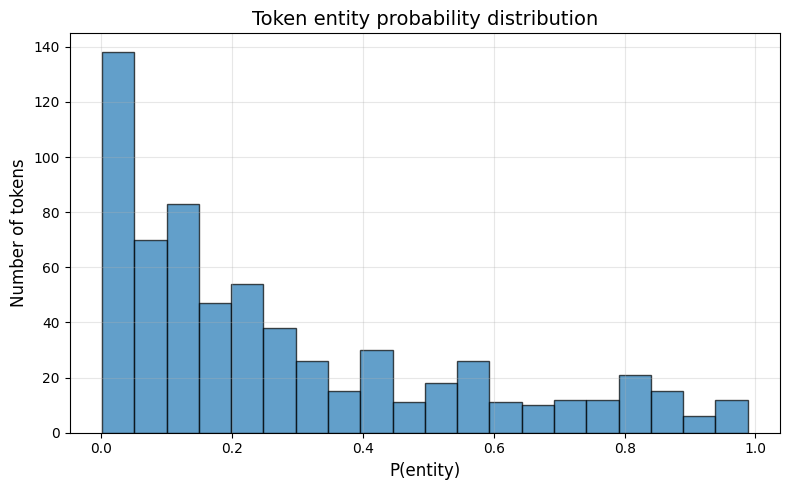


Examples of ambiguous tokens:


,token,total,entity_prob,ent_count,o_count
7364,falls,6,0.166667,1,5
6905,county,35,0.685714,24,11
7534,miles,54,0.055556,3,51
7321,pork,5,0.200000,1,4
7391,real,13,0.153846,2,11
7682,said,1849,0.001622,3,1846
6861,states,76,0.789474,60,16
6896,supreme,11,0.727273,8,3
7123,communications,9,0.444444,4,5
6860,iss,19,0.789474,15,4



LOADING NER MODEL


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: dslim/bert-base-NER
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model labels: {0: 'O', 1: 'B-MISC', 2: 'I-MISC', 3: 'B-PER', 4: 'I-PER', 5: 'B-ORG', 6: 'I-ORG', 7: 'B-LOC', 8: 'I-LOC'}

EVALUATING ON 4453 TEST SAMPLES
Processed 50/4453 examples
Processed 100/4453 examples
Processed 150/4453 examples
Processed 200/4453 examples
Processed 250/4453 examples
Processed 300/4453 examples
Processed 350/4453 examples
Processed 400/4453 examples
Processed 450/4453 examples
Processed 500/4453 examples
Processed 550/4453 examples
Processed 600/4453 examples
Processed 650/4453 examples
Processed 700/4453 examples
Processed 750/4453 examples
Processed 800/4453 examples
Processed 850/4453 examples
Processed 900/4453 examples
Processed 950/4453 examples
Processed 1000/4453 examples
Processed 1050/4453 examples
Processed 1100/4453 examples
Processed 1150/4453 examples
Processed 1200/4453 examples
Processed 1250/4453 examples
Processed 1300/4453 examples
Processed 1350/4453 examples
Processed 1400/4453 examples
Processed 1450/4453 examples
Processed 1500/4453 examp

,O,ENT
O,49110,307
ENT,158,10283



=== Confusion Matrix: DEER ===


,O,ENT
O,49060,357
ENT,399,10042


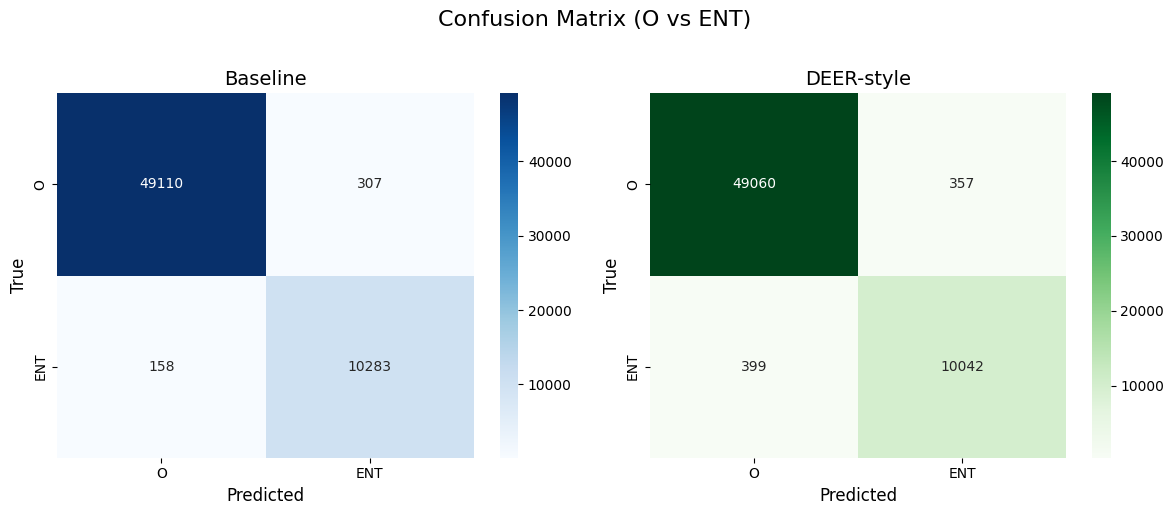

In [68]:
def main():
    print("Loading dataset...")
    dataset = load_dataset(config.dataset_name)
    train_data = dataset["train"]
    val_data = dataset["validation"]
    test_data = dataset["test"]
    
    print(f"Train: {len(train_data)} examples")
    print(f"Validation: {len(val_data)} examples")
    print(f"Test: {len(test_data)} examples")
    
    print("\nExample from training data:")
    print(train_data[0])
    
    bio_example = convert_ent_list_to_bio(train_data[0]['tokens'], train_data[0]['ent_list'])
    print("\nConverted to BIO tags:")
    for token, tag in zip(train_data[0]['tokens'], bio_example):
        print(f"{token:10} -> {tag}")
    
    print("\n" + "="*50)
    print("TOKEN STATISTICS ANALYSIS")
    print("="*50)
    token_stats = TokenStatistics(train_data, len(train_data))
    token_stats.print_summary()
    
    print("\n" + "="*50)
    print("LOADING NER MODEL")
    print("="*50)
    model = NERModel(config.model_name, config.device)
    
    post_processor = DeerPostProcessor(token_stats)
    
    print("\n" + "="*50)
    print(f"EVALUATING ON {len(test_data)} TEST SAMPLES")
    print("="*50)
    
    evaluator = Evaluator()
    test_subset = test_data.select(range(len(test_data)))
    
    for idx, example in enumerate(test_subset):
        tokens = example["tokens"]
        gold_labels = convert_ent_list_to_bio(tokens, example["ent_list"])
        
        base_predictions = model.predict(tokens)
        
        deer_predictions = post_processor.process(tokens, base_predictions)
        
        evaluator.add_example(gold_labels, base_predictions, deer_predictions)
        
        if (idx + 1) % 50 == 0:
            print(f"Processed {idx + 1}/{len(test_subset)} examples")
    
    print("\n" + "="*50)
    print("FINAL RESULTS")
    print("="*50)
    evaluator.print_comparison()
    evaluator.plot_confusion_matrices()


if __name__ == "__main__":
    main()

Видно, что метод DEER ухудшил предсказания. Модель чаще стала ошибаться и указывать именованные сущности, как прочее. F1-score упал в среднем на 10 процентов, поэтому, подводя итог, можно сказать, что конкретно для этого набора модель/датасет, метод DEER проявил себя плохо.